# Experiment: VAE Exploration

Objective:
- Train the first-pass VAE directly from this notebook.
- Inspect convergence, decoded samples, and saved run artifacts in one workflow.
- Keep the model code in `convoy_sim/vae.py`, but make the training workflow notebook-first.


## Workflow

This notebook is a test VAE training path.

Top-to-bottom flow:
1. set config and hyperparameters
2. run training from the notebook
3. load the generated run artifacts
4. inspect loss curves and decoded samples


In [1]:
from __future__ import annotations

import csv
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import DataLoader

from convoy_sim.attack_profiles import AttackProfile
from convoy_sim.profile_audit import AuditThresholds, audit_attack_profiles
from convoy_sim.profile_generation_viz import (
    apply_limits,
    combined_limits,
    plot_attack_example,
    plot_spawn_comparison,
    simple_ship_polygons,
    style_ax,
    torpedo_path_xy,
)
from convoy_sim.vae import AttackProfileVAE, AttackProfileVAEPreprocessor, build_vae_datasets, vae_loss
from scenarios.convoy_profiles import get_convoy_layout_profile
from convoy_sim.workflows import ensure_dir, git_sha, resolve_run_dir, write_json, write_yaml
from experiments.audit_attack_profile_dataset import load_dataset_records, flatten_dataset_records

PROJECT_ROOT = Path.cwd()
PROJECT_ROOT


PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project')

In [2]:
# Config: adjust here before running the notebook
TRAIN_PATH = Path("data/attack_profiles/synthetic/train_random_v2.jsonl")
VALID_PATH = Path("data/attack_profiles/synthetic/valid_random_v2.jsonl")
OUTPUT_ROOT = Path("results/runs")
RUN_NAME = "notebook"

SEED = 1945
EPOCHS = 50
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
BETA = 0.05
LATENT_DIM = 4
HIDDEN_DIM = 32
DEVICE = "auto"
NUM_WORKERS = 0
SAMPLE_COUNT = 16

# Training control
RUN_TRAINING = False
EXISTING_RUN_DIR: str | None = '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/vae/20260428_225419_notebook'

# Post-training sample audit config
AUDIT_SAMPLE_COUNT = 500
AUDIT_CONVOY_PROFILE = "convoy_layout_1"
AUDIT_CHECKPOINT_NAME = "model_best.pt"
AUDIT_SEED = 1945

TRAIN_COMPARE_LIMIT = 5000


## Helpers

The next cell mirrors the saved-run artifact pattern used elsewhere in the repo,
but keeps the training loop directly inside the notebook workflow.


In [3]:
def resolve_device(requested: str) -> str:
    if requested != "auto":
        return requested
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def mean_stats(stats_list: list[dict[str, float]]) -> dict[str, float]:
    if not stats_list:
        return {"loss": 0.0, "recon_loss": 0.0, "kl_loss": 0.0, "beta": 0.0}
    keys = stats_list[0].keys()
    return {key: float(np.mean([item[key] for item in stats_list], dtype=float)) for key in keys}

def train_one_epoch(model, data_loader, optimizer, device: str, beta: float) -> dict[str, float]:
    model.train()
    batch_stats = []
    for batch in data_loader:
        batch = batch.to(device)
        optimizer.zero_grad(set_to_none=True)
        recon, mu, logvar = model(batch)
        loss, stats = vae_loss(recon, batch, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()
        batch_stats.append(stats)
    return mean_stats(batch_stats)

def eval_one_epoch(model, data_loader, device: str, beta: float) -> dict[str, float]:
    model.eval()
    batch_stats = []
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            recon, mu, logvar = model(batch)
            _, stats = vae_loss(recon, batch, mu, logvar, beta=beta)
            batch_stats.append(stats)
    return mean_stats(batch_stats)

def write_history_csv(path: Path, history: list[dict[str, float]]) -> None:
    ensure_dir(path.parent)
    fieldnames = [
        "epoch",
        "train_loss",
        "train_recon_loss",
        "train_kl_loss",
        "valid_loss",
        "valid_recon_loss",
        "valid_kl_loss",
    ]
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        for row in history:
            writer.writerow(row)

def run_training_notebook() -> Path:
    overall_start = time.perf_counter()
    seed_everything(int(SEED))
    device = resolve_device(DEVICE)
    output_root = PROJECT_ROOT / OUTPUT_ROOT
    run_dir = resolve_run_dir(output_root, "vae", RUN_NAME)
    checkpoint_dir = run_dir / "checkpoints"
    ensure_dir(checkpoint_dir)

    data_start = time.perf_counter()
    train_ds, valid_ds, preprocessor = build_vae_datasets(
        train_path=PROJECT_ROOT / TRAIN_PATH,
        valid_path=PROJECT_ROOT / VALID_PATH,
    )
    data_seconds = time.perf_counter() - data_start

    generator = torch.Generator().manual_seed(int(SEED))
    train_loader = DataLoader(
        train_ds,
        batch_size=int(BATCH_SIZE),
        shuffle=True,
        generator=generator,
        num_workers=int(NUM_WORKERS),
    )
    valid_loader = DataLoader(
        valid_ds,
        batch_size=int(BATCH_SIZE),
        shuffle=False,
        num_workers=int(NUM_WORKERS),
    )

    model = AttackProfileVAE(latent_dim=int(LATENT_DIM), hidden_dim=int(HIDDEN_DIM)).to(device)
    optimizer = Adam(model.parameters(), lr=float(LEARNING_RATE))

    history = []
    best_valid_loss = float("inf")
    best_epoch = 0
    train_start = time.perf_counter()

    for epoch in range(1, int(EPOCHS) + 1):
        train_stats = train_one_epoch(model, train_loader, optimizer, device, float(BETA))
        valid_stats = eval_one_epoch(model, valid_loader, device, float(BETA))
        row = {
            "epoch": int(epoch),
            "train_loss": float(train_stats["loss"]),
            "train_recon_loss": float(train_stats["recon_loss"]),
            "train_kl_loss": float(train_stats["kl_loss"]),
            "valid_loss": float(valid_stats["loss"]),
            "valid_recon_loss": float(valid_stats["recon_loss"]),
            "valid_kl_loss": float(valid_stats["kl_loss"]),
        }
        history.append(row)
        best_marker = ""
        if row["valid_loss"] < best_valid_loss:
            best_valid_loss = row["valid_loss"]
            best_epoch = int(epoch)
            best_marker = " *best"
            torch.save({
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "preprocessor": preprocessor.to_dict(),
                "hyperparameters": {
                    "latent_dim": int(LATENT_DIM),
                    "hidden_dim": int(HIDDEN_DIM),
                    "learning_rate": float(LEARNING_RATE),
                    "batch_size": int(BATCH_SIZE),
                    "beta": float(BETA),
                },
            }, checkpoint_dir / "model_best.pt")
        print(
            f"epoch {epoch:03d} | "
            f"train_loss={row['train_loss']:.4f} "
            f"train_recon={row['train_recon_loss']:.4f} "
            f"train_kl={row['train_kl_loss']:.4f} | "
            f"valid_loss={row['valid_loss']:.4f} "
            f"valid_recon={row['valid_recon_loss']:.4f} "
            f"valid_kl={row['valid_kl_loss']:.4f}"
            f"{best_marker}"
        )

    training_seconds = time.perf_counter() - train_start
    torch.save({
        "epoch": int(EPOCHS),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "preprocessor": preprocessor.to_dict(),
        "hyperparameters": {
            "latent_dim": int(LATENT_DIM),
            "hidden_dim": int(HIDDEN_DIM),
            "learning_rate": float(LEARNING_RATE),
            "batch_size": int(BATCH_SIZE),
            "beta": float(BETA),
        },
    }, checkpoint_dir / "model_latest.pt")

    sample_start = time.perf_counter()
    model.eval()
    with torch.no_grad():
        decoded = model.sample(int(SAMPLE_COUNT), device=torch.device(device)).cpu().numpy()
    sample_payload = [
        preprocessor.decode_profile_fields(
            decoded[idx],
            profile_id=f"VAE_SAMPLE_{idx + 1:04d}",
            name=f"vae_sample_{idx + 1:04d}",
        )
        for idx in range(int(SAMPLE_COUNT))
    ]
    sample_seconds = time.perf_counter() - sample_start

    write_history_csv(run_dir / "training_history.csv", history)
    write_json(run_dir / "sampled_profiles.json", {"profiles": sample_payload})

    final_train = history[-1]
    best_row = history[best_epoch - 1]
    metrics_summary = {
        "dataset": {
            "train_samples": int(len(train_ds)),
            "valid_samples": int(len(valid_ds)),
            "input_dim": int(model.input_dim),
            "feature_names": list(preprocessor.feature_names),
        },
        "model": {
            "latent_dim": int(model.latent_dim),
            "hidden_dim": int(model.hidden_dim),
            "parameter_count": int(sum(int(p.numel()) for p in model.parameters())),
            "beta": float(BETA),
        },
        "training": {
            "epochs": int(EPOCHS),
            "batch_size": int(BATCH_SIZE),
            "learning_rate": float(LEARNING_RATE),
            "best_epoch": int(best_epoch),
            "final_train_loss": float(final_train["train_loss"]),
            "final_train_recon_loss": float(final_train["train_recon_loss"]),
            "final_train_kl_loss": float(final_train["train_kl_loss"]),
            "final_valid_loss": float(final_train["valid_loss"]),
            "final_valid_recon_loss": float(final_train["valid_recon_loss"]),
            "final_valid_kl_loss": float(final_train["valid_kl_loss"]),
            "best_valid_loss": float(best_row["valid_loss"]),
            "best_valid_recon_loss": float(best_row["valid_recon_loss"]),
            "best_valid_kl_loss": float(best_row["valid_kl_loss"]),
        },
        "samples": {
            "count": int(SAMPLE_COUNT),
            "output_file": "sampled_profiles.json",
        },
        "timing": {
            "dataset_load_seconds": float(data_seconds),
            "training_seconds": float(training_seconds),
            "sample_decode_seconds": float(sample_seconds),
            "total_seconds": float(time.perf_counter() - overall_start),
        },
    }
    manifest = {
        "workflow": "vae_train_notebook",
        "git_sha": git_sha(PROJECT_ROOT),
        "device": device,
        "seed": int(SEED),
        "train_path": str(TRAIN_PATH),
        "valid_path": str(VALID_PATH),
        "output_root": str(OUTPUT_ROOT),
        "run_name": str(RUN_NAME),
        "hyperparameters": {
            "epochs": int(EPOCHS),
            "batch_size": int(BATCH_SIZE),
            "learning_rate": float(LEARNING_RATE),
            "beta": float(BETA),
            "latent_dim": int(LATENT_DIM),
            "hidden_dim": int(HIDDEN_DIM),
            "sample_count": int(SAMPLE_COUNT),
        },
        "preprocessor": preprocessor.to_dict(),
        "artifacts": {
            "history_csv": "training_history.csv",
            "metrics_summary_json": "metrics_summary.json",
            "run_manifest_json": "run_manifest.json",
            "best_checkpoint": "checkpoints/model_best.pt",
            "latest_checkpoint": "checkpoints/model_latest.pt",
            "sampled_profiles_json": "sampled_profiles.json",
        },
    }
    resolved_cfg = {
        "dataset": {
            "train_path": str(TRAIN_PATH),
            "valid_path": str(VALID_PATH),
        },
        "training": {
            "epochs": int(EPOCHS),
            "batch_size": int(BATCH_SIZE),
            "learning_rate": float(LEARNING_RATE),
            "beta": float(BETA),
            "latent_dim": int(LATENT_DIM),
            "hidden_dim": int(HIDDEN_DIM),
            "device": device,
            "num_workers": int(NUM_WORKERS),
            "sample_count": int(SAMPLE_COUNT),
            "seed": int(SEED),
        },
    }

    write_yaml(run_dir / "config_resolved.yaml", resolved_cfg)
    write_json(run_dir / "metrics_summary.json", metrics_summary)
    write_json(run_dir / "run_manifest.json", manifest)
    return run_dir


MIN_SPAWN_CLEARANCE_M = 250.0
RANGE_PRESET_CENTERS_M = {"close": 1200.0, "medium": 2200.0, "long": 3200.0}
RANGE_BAND_TOLERANCE_M = 250.0
AUDIT_ACCEPTED_LABELS = {"credible_hit_threat", "credible_near_miss"}

def nearest_ship_clearance_m(u_pos: tuple[float, float], ships) -> float:
    u = np.asarray(u_pos, dtype=float)
    ship_positions = np.asarray([np.asarray(ship.position, dtype=float) for ship in ships], dtype=float)
    return float(np.min(np.linalg.norm(ship_positions - u, axis=1)))

def centroid_range_and_band(u_pos: tuple[float, float], ships) -> tuple[float, str, bool]:
    u = np.asarray(u_pos, dtype=float)
    centroid = np.mean(np.asarray([np.asarray(ship.position, dtype=float) for ship in ships], dtype=float), axis=0)
    centroid_range = float(np.linalg.norm(u - centroid))
    band_name, band_center = min(RANGE_PRESET_CENTERS_M.items(), key=lambda item: abs(centroid_range - item[1]))
    band_ok = abs(centroid_range - float(band_center)) <= float(RANGE_BAND_TOLERANCE_M)
    return centroid_range, str(band_name), bool(band_ok)

def sample_profiles_from_checkpoint(run_dir: Path, *, checkpoint_name: str, sample_count: int, device: str = "cpu"):
    manifest = json.loads((run_dir / "run_manifest.json").read_text(encoding="utf-8"))
    checkpoint = torch.load(run_dir / "checkpoints" / checkpoint_name, map_location=device)
    preprocessor_payload = checkpoint.get("preprocessor", manifest["preprocessor"])
    preprocessor = AttackProfileVAEPreprocessor.from_dict(preprocessor_payload)
    hyper = checkpoint.get("hyperparameters", manifest["hyperparameters"])
    model = AttackProfileVAE(latent_dim=int(hyper["latent_dim"]), hidden_dim=int(hyper["hidden_dim"]))
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    with torch.no_grad():
        decoded = model.sample(int(sample_count), device=torch.device(device)).cpu().numpy()
    payloads = [
        preprocessor.decode_profile_fields(
            decoded[idx],
            profile_id=f"VAE_AUDIT_{idx + 1:04d}",
            name=f"vae_audit_{idx + 1:04d}",
        )
        for idx in range(int(sample_count))
    ]
    return payloads, preprocessor, manifest

def audit_decoded_payloads(payloads: list[dict], *, convoy_profile: str):
    ships = get_convoy_layout_profile(convoy_profile).build_ships()
    profiles = [AttackProfile(**payload) for payload in payloads]
    audit_rows = audit_attack_profiles(profiles, ships, thresholds=AuditThresholds())
    audit_by_id = {row["profile_id"]: row for row in audit_rows}
    summary_rows = []
    for payload in payloads:
        row = dict(audit_by_id[payload["profile_id"]])
        clearance_m = nearest_ship_clearance_m(tuple(payload["u_pos"]), ships)
        centroid_range_m, inferred_range_band, band_ok = centroid_range_and_band(tuple(payload["u_pos"]), ships)
        clearance_ok = clearance_m >= float(MIN_SPAWN_CLEARANCE_M)
        label_ok = str(row["suggested_label"]) in AUDIT_ACCEPTED_LABELS
        passes = bool(clearance_ok and band_ok and label_ok)
        row.update({
            "clearance_m": float(clearance_m),
            "clearance_ok": bool(clearance_ok),
            "centroid_range_m": float(centroid_range_m),
            "inferred_range_band": inferred_range_band,
            "range_band_ok": bool(band_ok),
            "passes_gate": passes,
            "u_pos": list(payload["u_pos"]),
            "profile_payload": payload,
        })
        summary_rows.append(row)
    return ships, profiles, audit_rows, pd.DataFrame(summary_rows)

def build_torpedoes_for_profile(profile: AttackProfile, ships, *, seed: int = 1945):
    rng = np.random.default_rng(int(seed))
    return profile.build_torpedoes(rng, ships=ships)


# Shared profile-generation plotting helpers are imported from convoy_sim.profile_generation_viz.

def snap_payloads_to_nearest_range_band(payloads: list[dict], ships):
    ship_positions = np.asarray([np.asarray(ship.position, dtype=float) for ship in ships], dtype=float)
    centroid = np.mean(ship_positions, axis=0)
    snapped = []
    for payload in payloads:
        new_payload = dict(payload)
        u = np.asarray(payload["u_pos"], dtype=float)
        vec = u - centroid
        radius = float(np.linalg.norm(vec))
        if radius <= 1e-9:
            snapped.append(new_payload)
            continue
        band_center = min(RANGE_PRESET_CENTERS_M.values(), key=lambda v: abs(radius - v))
        snapped_u = centroid + (vec / radius) * float(band_center)
        new_payload["u_pos"] = [float(snapped_u[0]), float(snapped_u[1])]
        snapped.append(new_payload)
    return snapped


## Train Or Load Existing Run

- If `RUN_TRAINING = True`, this cell launches a fresh run and stores its artifacts.
- If `RUN_TRAINING = False`, set `EXISTING_RUN_DIR` above and this cell will inspect that run instead.


In [4]:
if RUN_TRAINING:
    RUN_DIR = run_training_notebook()
else:
    if not EXISTING_RUN_DIR:
        raise ValueError("Set EXISTING_RUN_DIR when RUN_TRAINING is False")
    RUN_DIR = PROJECT_ROOT / EXISTING_RUN_DIR

RUN_DIR


PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/vae/20260428_225419_notebook')

In [5]:
METRICS_PATH = RUN_DIR / "metrics_summary.json"
MANIFEST_PATH = RUN_DIR / "run_manifest.json"
HISTORY_PATH = RUN_DIR / "training_history.csv"
SAMPLES_PATH = RUN_DIR / "sampled_profiles.json"

metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
history = pd.read_csv(HISTORY_PATH)
samples = json.loads(SAMPLES_PATH.read_text(encoding="utf-8"))["profiles"]

summary = {
    "train_samples": metrics["dataset"]["train_samples"],
    "valid_samples": metrics["dataset"]["valid_samples"],
    "latent_dim": metrics["model"]["latent_dim"],
    "hidden_dim": metrics["model"]["hidden_dim"],
    "parameter_count": metrics["model"]["parameter_count"],
    "beta": metrics["model"]["beta"],
    "best_epoch": metrics["training"]["best_epoch"],
    "best_valid_loss": metrics["training"]["best_valid_loss"],
    "final_valid_loss": metrics["training"]["final_valid_loss"],
    "device": manifest["device"],
    "total_seconds": metrics["timing"]["total_seconds"],
}
summary


{'train_samples': 5000,
 'valid_samples': 1000,
 'latent_dim': 4,
 'hidden_dim': 32,
 'parameter_count': 3088,
 'beta': 0.05,
 'best_epoch': 50,
 'best_valid_loss': 0.40725259855389595,
 'final_valid_loss': 0.40725259855389595,
 'device': 'mps',
 'total_seconds': 15.998381499899551}

In [6]:
history.tail()


,epoch,train_loss,train_recon_loss,train_kl_loss,valid_loss,valid_recon_loss,valid_kl_loss
45,46,0.409288,0.160290,4.979958,0.409891,0.164754,4.902743
46,47,0.410279,0.162011,4.965367,0.410746,0.161923,4.976459
47,48,0.406209,0.157710,4.969995,0.412689,0.164664,4.960498
48,49,0.409128,0.160378,4.974986,0.411643,0.161197,5.008915
49,50,0.406861,0.156772,5.001795,0.407253,0.162013,4.904783


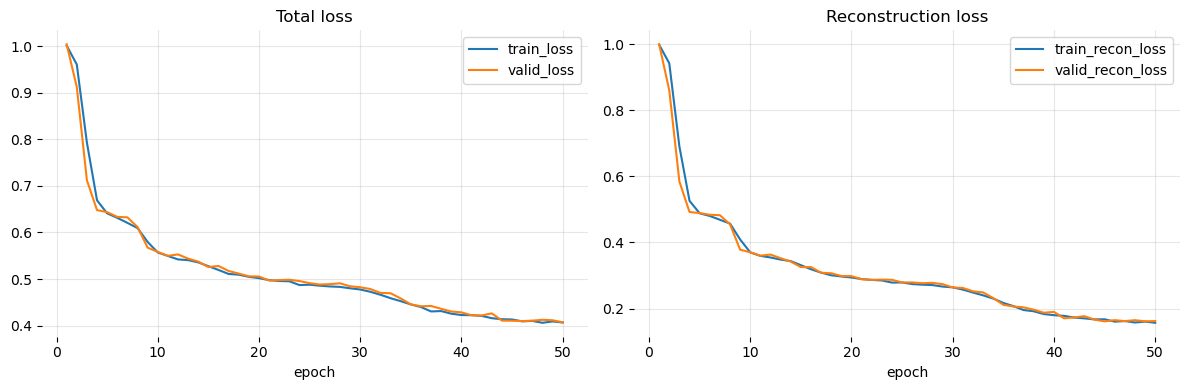

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history.plot(x="epoch", y=["train_loss", "valid_loss"], ax=axes[0], title="Total loss")
history.plot(x="epoch", y=["train_recon_loss", "valid_recon_loss"], ax=axes[1], title="Reconstruction loss")
axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(False)
plt.tight_layout()
plt.show()


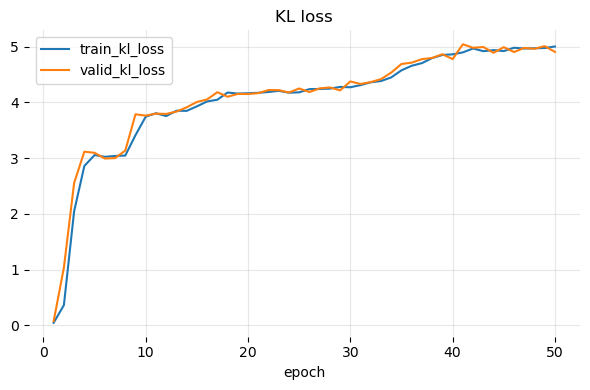

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
history.plot(x="epoch", y=["train_kl_loss", "valid_kl_loss"], ax=ax, title="KL loss")
ax.grid(True, alpha=0.3)
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()


## Decoded Sample Inspection

These are latent-prior samples decoded directly through the VAE and saved with the run.
They are not yet passed through post-decode feasibility + audit gating.


In [9]:
samples_df = pd.DataFrame(samples)
samples_df[["profile_id", "u_pos", "base_bearing_rad", "spread_rad", "launch_delay_s", "salvo_interval_s", "u_boat_initial_speed_mps"]]


,profile_id,u_pos,base_bearing_rad,spread_rad,launch_delay_s,salvo_interval_s,u_boat_initial_speed_mps
0,VAE_SAMPLE_0001,"[-947.7807006835938, 1926.8245849609375]",-1.137039,0.107635,2.258802,1.754332,1.379737
1,VAE_SAMPLE_0002,"[1675.76513671875, 677.741455078125]",-2.818812,0.113369,3.137887,2.376405,1.414524
2,VAE_SAMPLE_0003,"[-1211.629638671875, -1933.0164794921875]",1.030507,0.283092,2.376021,2.985550,1.454996
3,VAE_SAMPLE_0004,"[1308.2032470703125, 1680.6220703125]",-2.245328,0.098412,0.937765,1.719915,1.770451
4,VAE_SAMPLE_0005,"[-2396.117919921875, -223.2628173828125]",0.099869,0.091548,1.684171,2.913359,1.764124
5,VAE_SAMPLE_0006,"[1691.48095703125, 215.42535400390625]",-3.017372,0.097237,2.367764,2.275432,1.866027
6,VAE_SAMPLE_0007,"[2035.7984619140625, -204.14268493652344]",2.999978,0.105274,1.135624,1.733613,1.921024
7,VAE_SAMPLE_0008,"[-2008.2469482421875, 620.3154296875]",-0.412891,0.237716,1.009824,2.079577,1.550117
8,VAE_SAMPLE_0009,"[171.76913452148438, -1379.8656005859375]",1.690953,0.093736,0.577780,2.346625,1.976655
9,VAE_SAMPLE_0010,"[1184.3560791015625, 1780.167236328125]",-2.160072,0.090598,0.467748,2.538430,1.798983


In [10]:
samples_df[["spread_rad", "launch_delay_s", "salvo_interval_s", "u_boat_initial_speed_mps"]].describe()


,spread_rad,launch_delay_s,salvo_interval_s,u_boat_initial_speed_mps
count,16.000000,16.000000,16.000000,16.000000
mean,0.158401,1.500994,2.126644,1.629086
std,0.071039,0.750758,0.490085,0.292958
min,0.090598,0.467748,1.508757,1.117668
25%,0.098119,0.960050,1.716577,1.405827
50%,0.118892,1.367530,1.966739,1.657121
75%,0.220305,2.075224,2.416911,1.879776
max,0.283092,3.137887,2.985550,2.000000


## Post-Decode Audit

This section resamples directly from the saved checkpoint so you can change the audit sample count
without retraining. It then applies notebook-side gating that mirrors the current generator logic:
- nearest-ship clearance (`250 m`)
- inferred range-band sanity
- geometry plausibility audit label


In [11]:
AUDIT_PAYLOADS, AUDIT_PREPROCESSOR, AUDIT_MANIFEST = sample_profiles_from_checkpoint(
    RUN_DIR,
    checkpoint_name=AUDIT_CHECKPOINT_NAME,
    sample_count=int(AUDIT_SAMPLE_COUNT),
    device="cpu",
)
AUDIT_SHIPS, AUDIT_PROFILES, AUDIT_ROWS, audit_df = audit_decoded_payloads(
    AUDIT_PAYLOADS,
    convoy_profile=AUDIT_CONVOY_PROFILE,
)
audit_df.head()


,profile_id,name,mode,u_pos_x,u_pos_y,range_to_centroid_m,centroid_bearing_rad,range_to_target_m,target_bearing_rad,intent_bearing_rad,...,approach_side,intended_label,clearance_m,clearance_ok,centroid_range_m,inferred_range_band,range_band_ok,passes_gate,u_pos,profile_payload
0,VAE_AUDIT_0001,vae_audit_0001,fan,-853.365662,1946.518433,2125.362783,-1.157626,2125.362783,-1.157626,-1.157626,...,,,598.840091,True,2125.362783,medium,True,True,"[-853.3656616210938, 1946.5184326171875]","{'profile_id': 'VAE_AUDIT_0001', 'name': 'vae_..."
1,VAE_AUDIT_0002,vae_audit_0002,fan,-1354.765625,-1590.855713,2089.548228,0.865377,2089.548228,0.865377,0.865377,...,,,304.824126,True,2089.548228,medium,True,True,"[-1354.765625, -1590.855712890625]","{'profile_id': 'VAE_AUDIT_0002', 'name': 'vae_..."
2,VAE_AUDIT_0003,vae_audit_0003,fan,368.566315,1028.347290,1092.400694,-1.914940,1092.400694,-1.914940,-1.914940,...,,,370.692584,True,1092.400694,close,True,True,"[368.5663146972656, 1028.3472900390625]","{'profile_id': 'VAE_AUDIT_0003', 'name': 'vae_..."
3,VAE_AUDIT_0004,vae_audit_0004,fan,-1271.273071,1267.526978,1795.204685,-0.783923,1795.204685,-0.783923,-0.783923,...,,,165.182247,False,1795.204685,medium,False,False,"[-1271.2730712890625, 1267.5269775390625]","{'profile_id': 'VAE_AUDIT_0004', 'name': 'vae_..."
4,VAE_AUDIT_0005,vae_audit_0005,fan,-1181.444214,-2027.006958,2346.181502,1.043081,2346.181502,1.043081,1.043081,...,,,656.533501,True,2346.181502,medium,True,True,"[-1181.4442138671875, -2027.0069580078125]","{'profile_id': 'VAE_AUDIT_0005', 'name': 'vae_..."


In [12]:
audit_summary = {
    "sample_count": int(len(audit_df)),
    "accepted_count": int(audit_df["passes_gate"].sum()),
    "rejected_count": int((~audit_df["passes_gate"]).sum()),
    "acceptance_rate": float(audit_df["passes_gate"].mean()) if len(audit_df) else 0.0,
    "label_counts": audit_df["suggested_label"].value_counts().to_dict(),
    "accepted_label_counts": audit_df.loc[audit_df["passes_gate"], "suggested_label"].value_counts().to_dict(),
    "clearance_failures": int((~audit_df["clearance_ok"]).sum()),
    "range_failures": int((~audit_df["range_band_ok"]).sum()),
}
audit_summary


{'sample_count': 500,
 'accepted_count': 315,
 'rejected_count': 185,
 'acceptance_rate': 0.63,
 'label_counts': {'credible_hit_threat': 483,
  'implausible_geometry': 15,
  'credible_near_miss': 2},
 'accepted_label_counts': {'credible_hit_threat': 314,
  'credible_near_miss': 1},
 'clearance_failures': 37,
 'range_failures': 163}

In [13]:
audit_df[["profile_id", "suggested_label", "bearing_error_deg", "clearance_m", "centroid_range_m", "inferred_range_band", "passes_gate"]].head(20)


,profile_id,suggested_label,bearing_error_deg,clearance_m,centroid_range_m,inferred_range_band,passes_gate
0,VAE_AUDIT_0001,credible_hit_threat,1.403558,598.840091,2125.362783,medium,True
1,VAE_AUDIT_0002,credible_hit_threat,0.354900,304.824126,2089.548228,medium,True
2,VAE_AUDIT_0003,credible_hit_threat,3.517572,370.692584,1092.400694,close,True
3,VAE_AUDIT_0004,credible_hit_threat,4.893950,165.182247,1795.204685,medium,False
4,VAE_AUDIT_0005,credible_hit_threat,2.883655,656.533501,2346.181502,medium,True
5,VAE_AUDIT_0006,credible_hit_threat,1.006989,292.196236,1972.271038,medium,True
6,VAE_AUDIT_0007,credible_hit_threat,2.150183,423.278356,2177.319679,medium,True
7,VAE_AUDIT_0008,credible_hit_threat,0.283657,402.017934,2175.610196,medium,True
8,VAE_AUDIT_0009,credible_hit_threat,2.849021,488.737134,2545.141945,medium,False
9,VAE_AUDIT_0010,credible_hit_threat,4.194941,1046.330455,2540.587713,medium,False


## Training Data vs VAE Spawn Comparison

This compares the raw synthetic training spawn distribution against the decoded VAE spawn distribution.
Both panels use the same ocean bounds for a direct visual comparison.


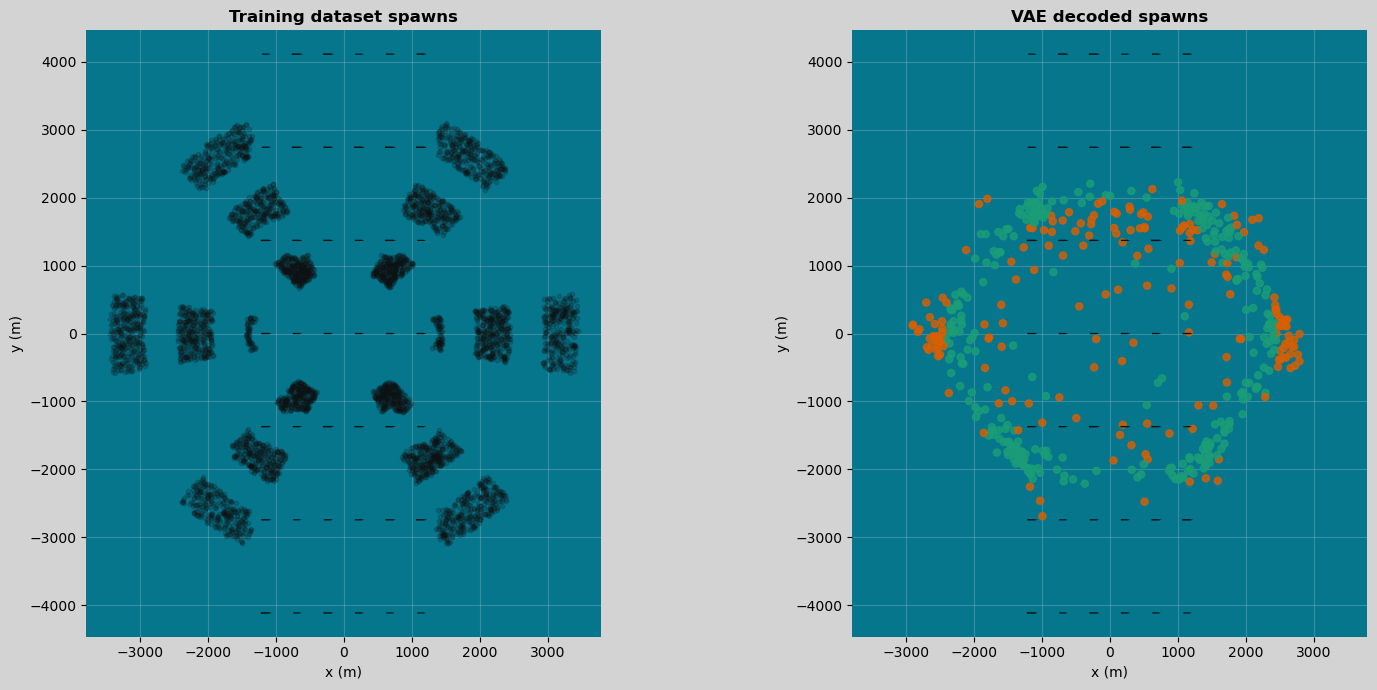

In [14]:
train_records = load_dataset_records(PROJECT_ROOT / TRAIN_PATH)
train_rows = flatten_dataset_records(train_records[: int(TRAIN_COMPARE_LIMIT)])
train_df = pd.DataFrame(train_rows)
train_df["u_pos"] = train_df[["u_pos_x", "u_pos_y"]].values.tolist()

train_points = np.vstack(train_df["u_pos"].to_list()) if len(train_df) else None
vae_points = np.vstack(audit_df["u_pos"].to_list()) if len(audit_df) else None
extra_sets = [p for p in [train_points, vae_points] if p is not None]
shared_limits_compare = combined_limits(AUDIT_SHIPS, extra_points=np.vstack(extra_sets) if extra_sets else None, pad=350.0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="lightgrey")
style_ax(axes[0], "Training dataset spawns")
simple_ship_polygons(axes[0], AUDIT_SHIPS)
if len(train_df):
    train_xy = np.vstack(train_df["u_pos"].to_list())
    axes[0].scatter(train_xy[:, 0], train_xy[:, 1], c="#111111", s=10, alpha=0.18, zorder=2)
apply_limits(axes[0], shared_limits_compare)
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")

plot_spawn_comparison(axes[1], AUDIT_SHIPS, audit_df, title="VAE decoded spawns", accepted_only=False, limits=shared_limits_compare)
plt.tight_layout()
# plt.savefig("Training-VAE-Compare-V1.png")
plt.show()


## Radius-Snap Audit Test

This tests a simple postprocess: snap each decoded spawn radius to the nearest valid band center (`1200`, `2200`, `3200`) while keeping direction unchanged.
If acceptance rises materially, then range-band smoothing is the main problem.


In [15]:
snapped_payloads = snap_payloads_to_nearest_range_band(AUDIT_PAYLOADS, AUDIT_SHIPS)
SNAP_SHIPS, SNAP_PROFILES, SNAP_AUDIT_ROWS, snap_df = audit_decoded_payloads(snapped_payloads, convoy_profile=AUDIT_CONVOY_PROFILE)
snap_summary = {
    "sample_count": int(len(snap_df)),
    "accepted_count": int(snap_df["passes_gate"].sum()),
    "rejected_count": int((~snap_df["passes_gate"]).sum()),
    "acceptance_rate": float(snap_df["passes_gate"].mean()) if len(snap_df) else 0.0,
    "label_counts": snap_df["suggested_label"].value_counts().to_dict(),
    "accepted_label_counts": snap_df.loc[snap_df["passes_gate"], "suggested_label"].value_counts().to_dict(),
    "clearance_failures": int((~snap_df["clearance_ok"]).sum()),
    "range_failures": int((~snap_df["range_band_ok"]).sum()),
}
snap_summary


{'sample_count': 500,
 'accepted_count': 468,
 'rejected_count': 32,
 'acceptance_rate': 0.936,
 'label_counts': {'credible_hit_threat': 483,
  'implausible_geometry': 15,
  'credible_near_miss': 2},
 'accepted_label_counts': {'credible_hit_threat': 466,
  'credible_near_miss': 2},
 'clearance_failures': 17,
 'range_failures': 0}

## Visual Check: Before vs After Gating

These are intentionally simple scatter views.
Left: all decoded checkpoint samples. Right: only samples that passed gating.
Green means accepted. Orange means rejected.


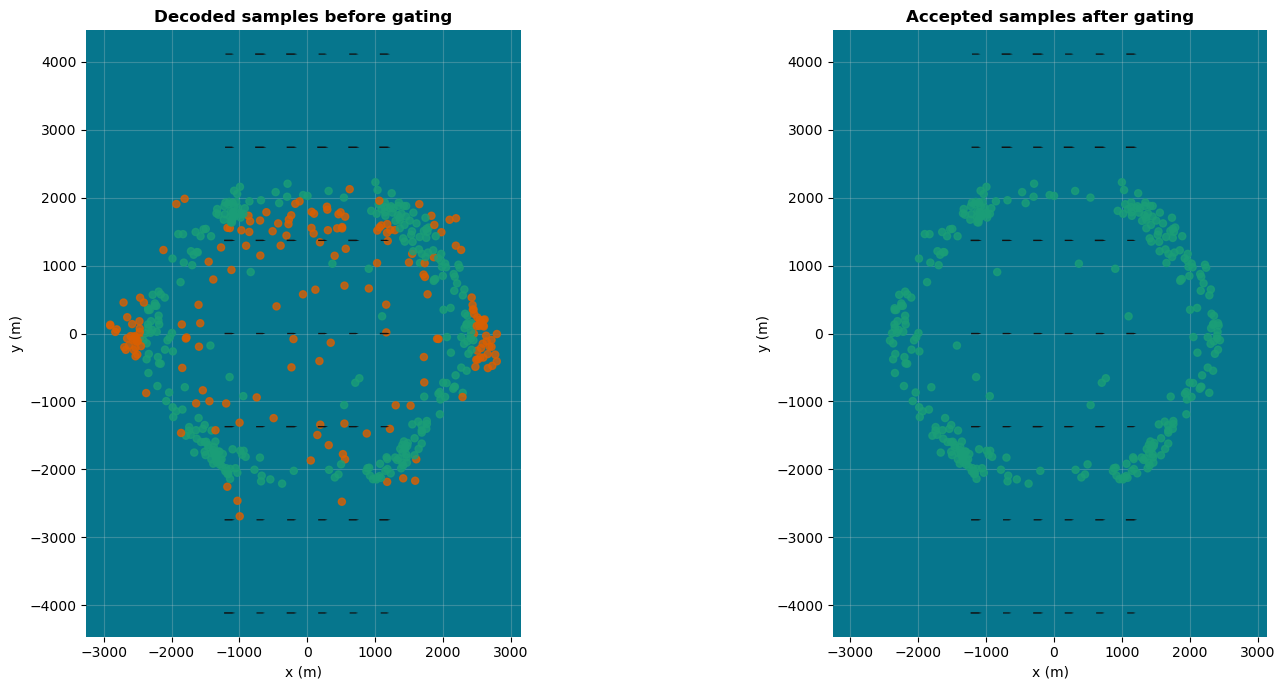

In [16]:
all_points = np.vstack(audit_df["u_pos"].to_list()) if len(audit_df) else None
shared_limits = combined_limits(AUDIT_SHIPS, extra_points=all_points, pad=350.0)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="white")
plot_spawn_comparison(axes[0], AUDIT_SHIPS, audit_df, title="Decoded samples before gating", accepted_only=False, limits=shared_limits)
plot_spawn_comparison(axes[1], AUDIT_SHIPS, audit_df, title="Accepted samples after gating", accepted_only=True, limits=shared_limits)
plt.tight_layout()
plt.show()


## Visual Check: One Accepted vs One Rejected Attack

These are also intentionally simple.
They show ship centers, the sampled U-boat spawn, and the torpedo paths with minimal styling.


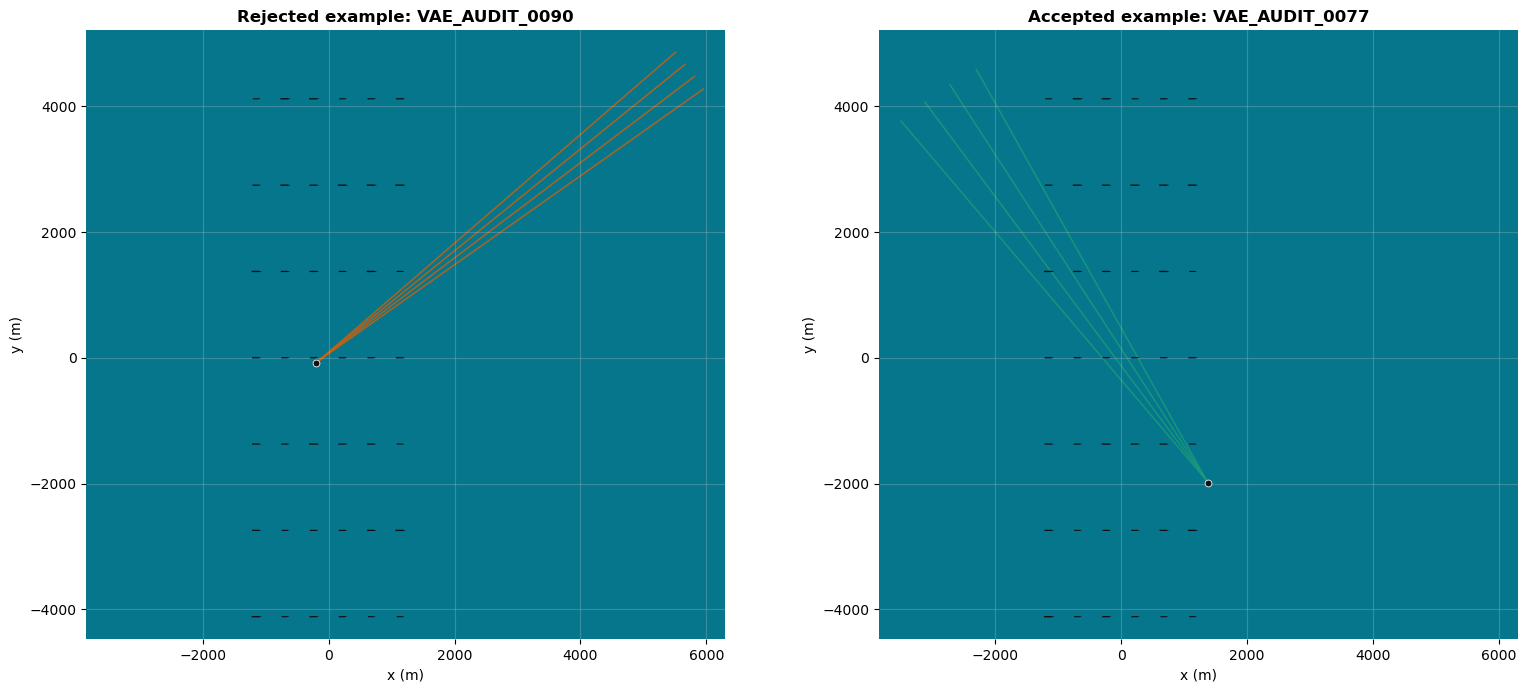

In [17]:
accepted_example = audit_df.loc[audit_df["passes_gate"]].sort_values(["severity", "profile_id"]).head(1)
rejected_example = audit_df.loc[~audit_df["passes_gate"]].sort_values(["severity", "profile_id"], ascending=[False, True]).head(1)

accepted_profile = AttackProfile(**accepted_example.iloc[0]["profile_payload"]) if len(accepted_example) else None
rejected_profile = AttackProfile(**rejected_example.iloc[0]["profile_payload"]) if len(rejected_example) else None

extra_paths = []
for profile in [p for p in [accepted_profile, rejected_profile] if p is not None]:
    rng = np.random.default_rng(int(AUDIT_SEED))
    torpedoes = profile.build_torpedoes(rng, ships=AUDIT_SHIPS)
    extra_paths.append(np.asarray([profile.u_pos], dtype=float))
    for torpedo in torpedoes:
        extra_paths.append(torpedo_path_xy(torpedo))
shared_limits = combined_limits(AUDIT_SHIPS, extra_points=np.vstack(extra_paths) if extra_paths else None, pad=350.0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="white")

if rejected_profile is not None:
    plot_attack_example(
        axes[0],
        AUDIT_SHIPS,
        rejected_profile,
        title=f"Rejected example: {rejected_profile.profile_id}",
        accepted=False,
        seed=AUDIT_SEED,
        limits=shared_limits,
    )
else:
    axes[0].set_title("No rejected sample in batch")
    axes[0].axis("off")

if accepted_profile is not None:
    plot_attack_example(
        axes[1],
        AUDIT_SHIPS,
        accepted_profile,
        title=f"Accepted example: {accepted_profile.profile_id}",
        accepted=True,
        seed=AUDIT_SEED,
        limits=shared_limits,
    )
else:
    axes[1].set_title("No accepted sample in batch")
    axes[1].axis("off")

plt.tight_layout()
plt.show()
